In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/train.csv")
df['date'] = pd.to_datetime(df['date'])

print(df.shape)
print(df.head())
print(df.isnull().sum())


(913000, 4)
        date  store  item  sales
0 2013-01-01      1     1     13
1 2013-01-02      1     1     11
2 2013-01-03      1     1     14
3 2013-01-04      1     1     13
4 2013-01-05      1     1     10
date     0
store    0
item     0
sales    0
dtype: int64


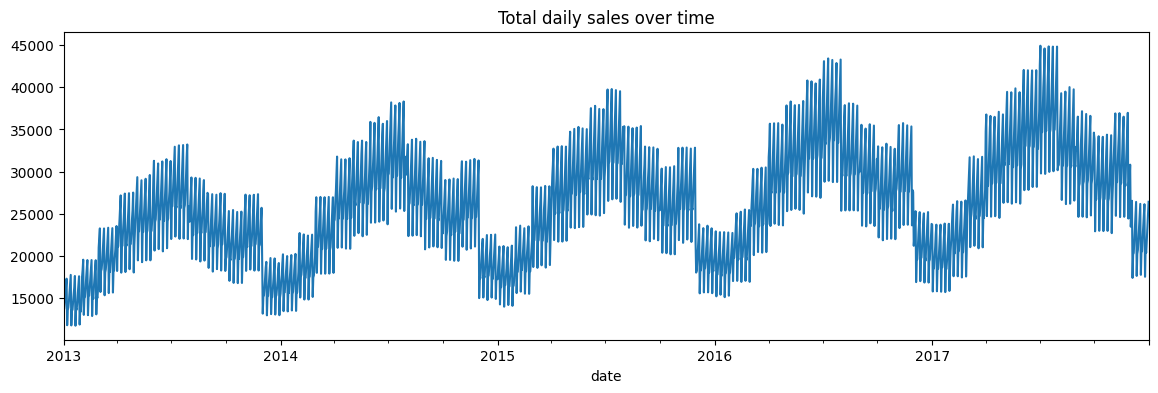

In [12]:
daily_sales = df.groupby('date')['sales'].sum()
daily_sales.plot(figsize=(14,4), title="Total daily sales over time")
plt.show()

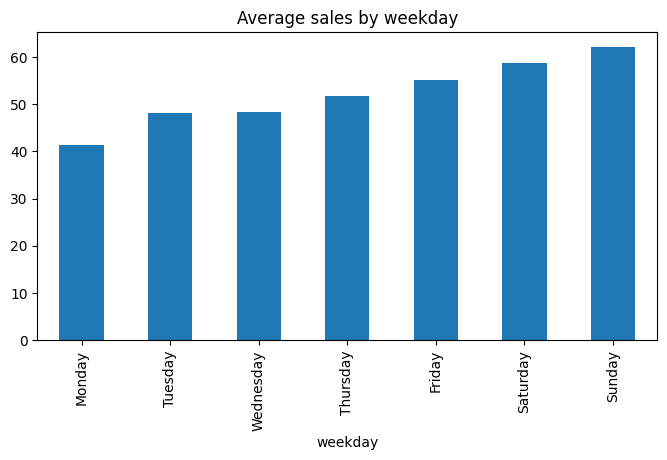

In [13]:
df['weekday'] = df['date'].dt.day_name()
df.groupby('weekday')['sales'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
).plot(kind='bar', figsize=(8,4), title="Average sales by weekday")
plt.show()

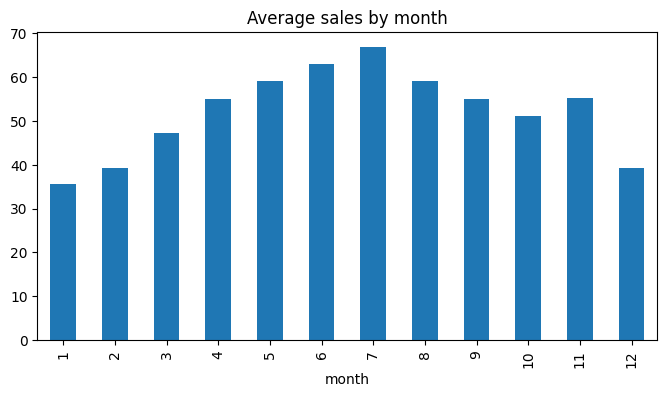

In [14]:
df['month'] = df['date'].dt.month
df.groupby('month')['sales'].mean().plot(kind='bar', figsize=(8,4), title="Average sales by month")
plt.show()

In [15]:
# Pick one store + item to build the first working model
sample = df[(df['store'] == 1) & (df['item'] == 1)].copy()
sample = sample.rename(columns={'date': 'ds', 'sales': 'y'})[['ds', 'y']]
sample.head()

,ds,y
0,2013-01-01,13
1,2013-01-02,11
2,2013-01-03,14
3,2013-01-04,13
4,2013-01-05,10


In [16]:
from prophet import Prophet

model = Prophet(yearly_seasonality=True, weekly_seasonality=True)
model.fit(sample)

15:27:18 - cmdstanpy - INFO - Chain [1] start processing
15:27:18 - cmdstanpy - INFO - Chain [1] done processing


In [19]:
from prophet import  

model = Prophet(yearly_seasonality=True, weekly_seasonality=True)
model.fit(sample)

SyntaxError: invalid syntax (3270778333.py, line 1)

In [18]:
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1911,2018-03-27,20.583729,15.114426,26.465077
1912,2018-03-28,21.260736,15.688089,27.330863
1913,2018-03-29,21.971965,16.196317,27.405383
1914,2018-03-30,23.588095,17.747896,28.762116
1915,2018-03-31,25.600659,19.905741,31.136459


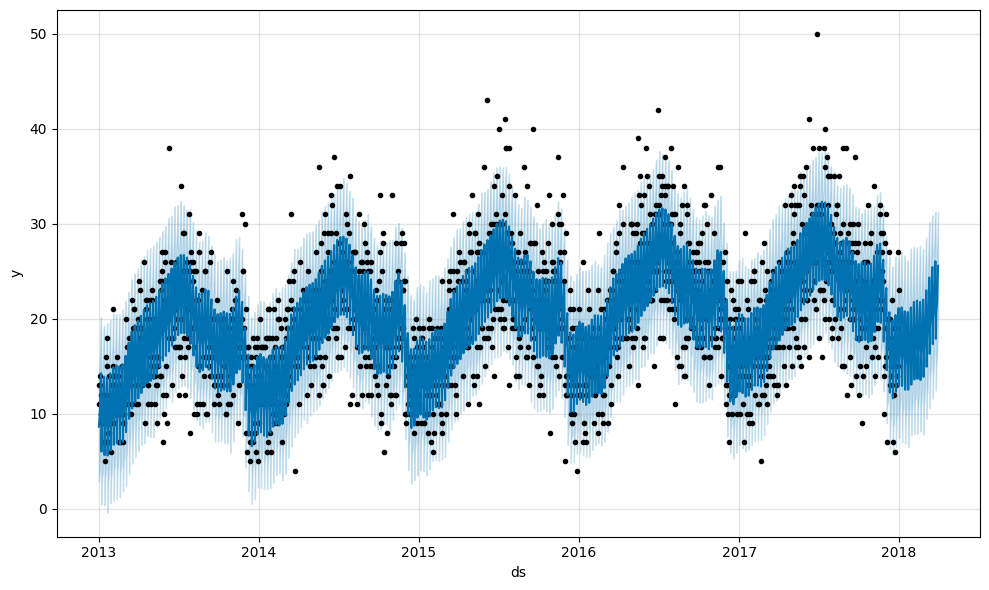

In [9]:
fig1 = model.plot(forecast)

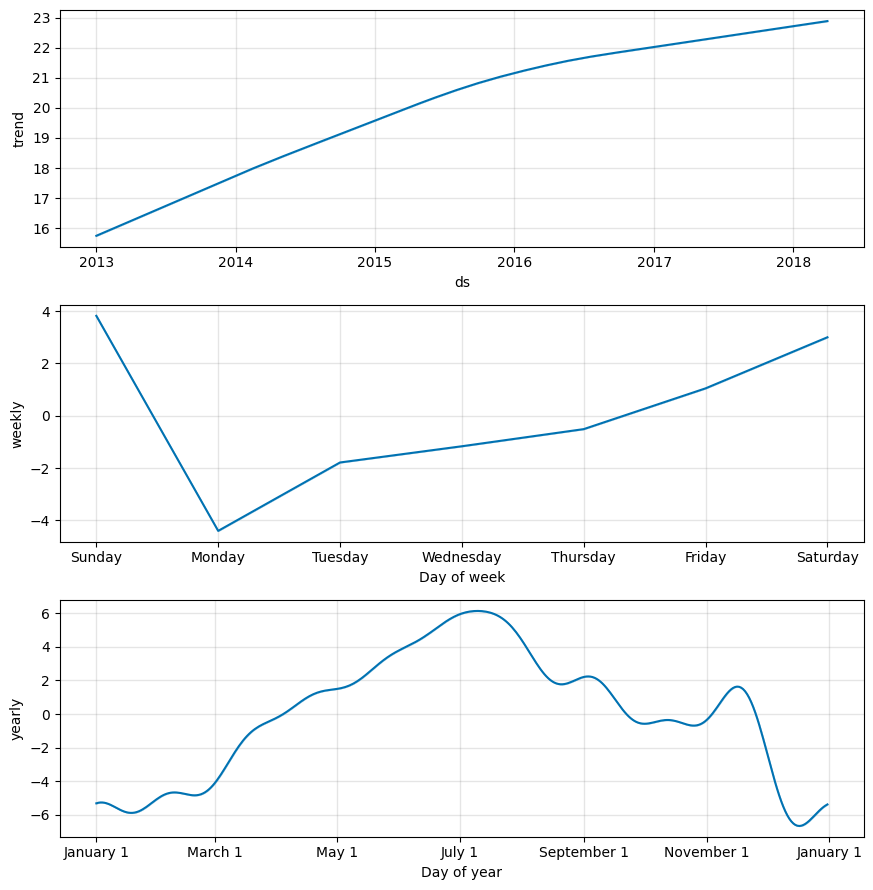

In [20]:
fig2 = model.plot_components(forecast)

In [11]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

train = sample.iloc[:-90] //SEEN
test = sample.iloc[-90:] // UNSEEN

model2 = Prophet(yearly_seasonality=True, weekly_seasonality=True)
model2.fit(train)

future2 = model2.make_future_dataframe(periods=90)
forecast2 = model2.predict(future2)

pred = forecast2.set_index('ds').loc[test['ds']]['yhat'].values
actual = test['y'].values

mae = mean_absolute_error(actual, pred)
mape = mean_absolute_percentage_error(actual, pred)
print(f"MAE: {mae:.2f}, MAPE: {mape*100:.2f}%")

17:27:50 - cmdstanpy - INFO - Chain [1] start processing
17:27:51 - cmdstanpy - INFO - Chain [1] done processing


MAE: 3.76, MAPE: 23.25%


In [21]:
model3 = Prophet(yearly_seasonality=True, weekly_seasonality=True, changepoint_prior_scale=0.5)
model3.fit(train)

future3 = model3.make_future_dataframe(periods=90)
forecast3 = model3.predict(future3)

pred3 = forecast3.set_index('ds').loc[test['ds']]['yhat'].values
mape3 = mean_absolute_percentage_error(actual, pred3)
print(f"MAPE with tuning: {mape3*100:.2f}%")

NameError: name 'train' is not defined

In [23]:
import warnings
warnings.filterwarnings("ignore")

results = []

for store_id in df['store'].unique():
    for item_id in df['item'].unique():
        subset = df[(df['store'] == store_id) & (df['item'] == item_id)].copy()
        subset = subset.rename(columns={'date': 'ds', 'sales': 'y'})[['ds', 'y']]

        m = Prophet(yearly_seasonality=True, weekly_seasonality=True)
        m.fit(subset)

        future = m.make_future_dataframe(periods=30)
        fc = m.predict(future)
        fc_tail = fc[['ds', 'yhat']].tail(30).copy()
        fc_tail['store'] = store_id
        fc_tail['item'] = item_id

        results.append(fc_tail)

all_forecasts = pd.concat(results, ignore_index=True)
all_forecasts.to_csv("../data/all_forecasts.csv", index=False)
print(all_forecasts.shape)

15:35:10 - cmdstanpy - INFO - Chain [1] start processing
15:35:10 - cmdstanpy - INFO - Chain [1] done processing
15:35:11 - cmdstanpy - INFO - Chain [1] start processing
15:35:11 - cmdstanpy - INFO - Chain [1] done processing
15:35:12 - cmdstanpy - INFO - Chain [1] start processing
15:35:12 - cmdstanpy - INFO - Chain [1] done processing
15:35:12 - cmdstanpy - INFO - Chain [1] start processing
15:35:13 - cmdstanpy - INFO - Chain [1] done processing
15:35:13 - cmdstanpy - INFO - Chain [1] start processing
15:35:13 - cmdstanpy - INFO - Chain [1] done processing
15:35:14 - cmdstanpy - INFO - Chain [1] start processing
15:35:14 - cmdstanpy - INFO - Chain [1] done processing
15:35:15 - cmdstanpy - INFO - Chain [1] start processing
15:35:15 - cmdstanpy - INFO - Chain [1] done processing
15:35:16 - cmdstanpy - INFO - Chain [1] start processing
15:35:16 - cmdstanpy - INFO - Chain [1] done processing
15:35:16 - cmdstanpy - INFO - Chain [1] start processing
15:35:17 - cmdstanpy - INFO - Chain [1]

(15000, 4)
